In [1]:
import sys
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LightSource
from sklearn.preprocessing import QuantileTransformer
import skgstat as skg
from skgstat import models
import gstatsim_torch as gst
import parallel_torch as gspt
import torch
import math

In [2]:
df_bed = pd.read_csv('../demos/data/greenland_test_data.csv')

# remove erroneously high values due to bad bed picks
df_bed = df_bed[df_bed["Bed"] <= 700]  

In [3]:
# grid data to 100 m resolution and remove coordinates with NaNs
res = 1000
df_grid, torch_data, rows, cols = gst.Gridding.grid_data(df_bed, 'X', 'Y', 'Bed', res)
df_grid = df_grid[df_grid["Z"].isnull() == False]
torch_data = torch_data[torch_data[:,2].isnan() == False]
df_grid = df_grid.rename(columns = {"Z": "Bed"})

# normal score transformation
data = df_grid['Bed'].values.reshape(-1,1)
nst_trans = QuantileTransformer(n_quantiles=500, output_distribution="normal").fit(data)
df_grid['Nbed'] = nst_trans.transform(data)

# compute experimental (isotropic) variogram
coords = df_grid[['X','Y']].values
values = df_grid['Nbed']
torch_data[:,2] = torch.tensor(df_grid['Nbed'].to_numpy())

maxlag = 50000             # maximum range distance
n_lags = 70                # num of bins

V1 = skg.Variogram(coords, values, bin_func='even', n_lags=n_lags, 
                   maxlag=maxlag, normalize=False)

# use exponential variogram model
V1.model = 'exponential'
V1.parameters

[np.float64(31852.50086471171), np.float64(0.7027444991649647), 0]

In [4]:
# define coordinate grid
xmin = torch.min(torch_data[:,0]); xmax = torch.max(torch_data[:,0])     # min and max x values
ymin = torch.min(torch_data[:,1]); ymax = torch.max(torch_data[:,1])     # min and max y values

Pred_grid_xy = gst.Gridding.prediction_grid(xmin, xmax, ymin, ymax, res)

In [5]:
# set variogram parameters
azimuth = 0
nugget = V1.parameters[2]

# the major and minor ranges are the same in this example because it is isotropic
major_range = V1.parameters[0]
minor_range = V1.parameters[0]
sill = V1.parameters[1]
vtype = 'Exponential'

# save variogram parameters as a list
vario = [azimuth, nugget, major_range, minor_range, sill, vtype]


k = 48         # number of neighboring data points used to estimate a given point
rad = 50000     # 50 km search radius

In [6]:
%time s_krig_sgs = gspt.skrige_sgs_parallel(Pred_grid_xy, torch_data, k, vario, rad, 3)

[W612 11:54:11.643631547 CudaIPCTypes.cpp:96] Producer process tried to deallocate over 1000 memory blocks referred by consumer processes. Deallocation might be significantly slowed down. We assume it will never going to be the case, but if it is, please file but to https://github.com/pytorch/pytorch
[W612 11:54:12.311022605 CudaIPCTypes.cpp:96] Producer process tried to deallocate over 1000 memory blocks referred by consumer processes. Deallocation might be significantly slowed down. We assume it will never going to be the case, but if it is, please file but to https://github.com/pytorch/pytorch
[W612 11:54:12.516454567 CudaIPCTypes.cpp:96] Producer process tried to deallocate over 1000 memory blocks referred by consumer processes. Deallocation might be significantly slowed down. We assume it will never going to be the case, but if it is, please file but to https://github.com/pytorch/pytorch


CPU times: user 34.9 s, sys: 1.87 s, total: 36.7 s
Wall time: 2min 25s


In [7]:
# reverse normal score transformation
sim1 = s_krig_sgs.reshape(-1,1)
sim_trans = nst_trans.inverse_transform(sim1)

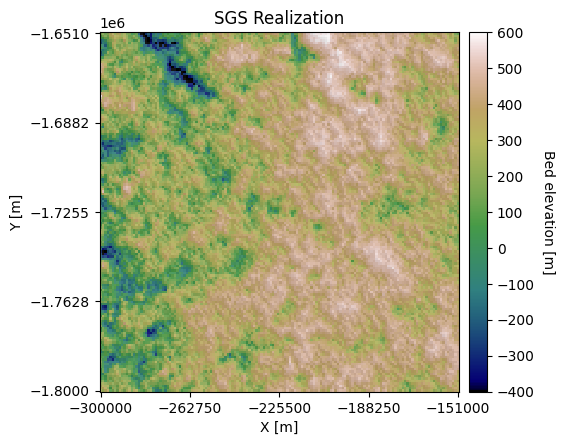

In [8]:
vmin = -400; vmax = 600
x_mat = Pred_grid_xy[:,0].reshape((rows, cols))
y_mat = Pred_grid_xy[:,1].reshape((rows, cols))
mat = sim_trans.reshape((rows, cols))
xmin = Pred_grid_xy[:,0].min(); xmax = Pred_grid_xy[:,0].max()
ymin = Pred_grid_xy[:,1].min(); ymax = Pred_grid_xy[:,1].max()
    
cmap=plt.get_cmap('gist_earth')
fig, ax = plt.subplots(1, figsize=(5,5))
im = ax.pcolormesh(x_mat, y_mat, mat, vmin=vmin, vmax=vmax, cmap=cmap)
    
# Shade from the northeast, with the sun 45 degrees from horizontal
ls = LightSource(azdeg=45, altdeg=45)
        
# leaving the dx and dy as 1 means a vertical exageration equal to dx/dy
hillshade = ls.hillshade(mat, vert_exag=1, dx=1, dy=1, fraction=1.0)
plt.pcolormesh(x_mat, y_mat, hillshade, cmap='gray', alpha=0.1)
plt.title('SGS Realization')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.xticks(np.linspace(xmin, xmax, 5))
plt.yticks(np.linspace(ymin, ymax, 5))

# make colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(-400, 600, 11), cax=cax)
cbar.set_label("Bed elevation [m]", rotation=270, labelpad=15)
ax.axis('scaled')
plt.show()